# Tutorial 30 — GaAs: frequency-dependent spin Hall conductivity

The waw-native reimagining of Wannier90 tutorial 30 -- postw90's `berry_task = shc` with `shc_freq_scan = true`: the spin Hall conductivity $\sigma^{xy}_z(\omega)$ as a function of **optical frequency** rather than Fermi energy (tutorial 29's static case). Same Qiao-method spin-current operator as tutorial 29, but a genuinely different accumulation formula -- a COMPLEX resonance denominator $-2/(\Delta\varepsilon^2 - (\omega+i\eta)^2)$ in place of the static case's real Lorentzian, giving a complex $\sigma(\omega)$ (Re = dissipative, Im = reactive response). GaAs is a zincblende semiconductor: DFT underestimates its gap, so this tutorial also exercises a scissors shift (`core.hamiltonian.apply_scissors_shift`) -- a rigid upward shift of the conduction manifold's eigenvalues that leaves every wavefunction-derived quantity (the position operator, $D_h$, the spin operators) exactly unchanged, since it commutes with $H(k)$ by construction.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Converged noncollinear+SOC DFT and Wannierisation
Zincblende GaAs, $a=5.654$ Å, fully-relativistic PAW pseudopotentials (`noncolin=True, lspinorb=True`) -- QE pslibrary's `Ga-rel`/`As-rel` (different from the scalar-relativistic PseudoDojo `Ga.upf`/`As.upf` used elsewhere in this series, since SOC needs full relativity). 16 spinor MLWFs: analytic $s+p$ trial orbitals at both sites (equivalent bonding character to the real tutorial's `sp3` hybrids), automatically spin-doubled 8->16 by `write_nnkp`'s spinor-projection block -- an **isolated** manifold (`num_bands == num_wann`, no disentanglement needed), matching the real tutorial's own `exclude_bands = 1-10` / `num_bands = num_wann = 16`.

In [2]:
from ase.build import bulk
from waw.interfaces.ase.structure import real_lattice, recip_lattice
from waw.interfaces.projections import spd_projections
from waw.core.hamiltonian import compute_position_r, apply_scissors_shift
from waw.units import EV_TO_HARTREE
from waw.analysis.spin_hall import build_shc_operators, spin_hall_conductivity_ac

atoms = bulk('GaAs', 'zincblende', a=5.654)
MP_GRID = (10, 10, 10)
WORK = HERE / 'runs' / 'gaas_shc'

SOC = dict(noncolin=True, lspinorb=True, ecutrho=1080,
           occupations='smearing', smearing='mv', degauss=0.002)

# s+p at both sites -> spinor-doubled to 16, the same bonding/antibonding
# manifold the real tutorial's As:sp3/Ga:sp3 hybrids span
projs = (spd_projections((0.25, 0.25, 0.25), 's') +
         spd_projections((0.25, 0.25, 0.25), 'p') +
         spd_projections((0.0, 0.0, 0.0), 's') +
         spd_projections((0.0, 0.0, 0.0), 'p'))

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'gaas_shc',
    ecutwfc=90, scf_kpts=(10, 10, 10), nbnd=26, num_wann=16,
    exclude_bands=list(range(1, 11)), projections=projs,
    system_extra=SOC,
    pseudopotentials={'Ga': 'Ga-rel.upf', 'As': 'As-rel.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES, write_spn=True,
    rerun_scf=False,
)
E_FERMI = ov['fermi_energy']

# isolated manifold (num_bands == num_wann): no outer/frozen window,
# no disentanglement -- result.dis is None, W == U_final
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=16,
    guiding_centres=True, optimizer='cg',
    n_restarts=1, n_iter=4000, conv_tol=1e-10, conv_window=40,
)
print(f'E_F (own SCF) = {E_FERMI:.4f} eV  (real tutorial: 7.9366 eV)')
print(f'Omega_total = {result.omega_final * BOHR_TO_ANG**2:.4f} Ang^2')

REAL = real_lattice(atoms)
RECIP = recip_lattice(atoms)
W = result.spread.U_final   # isolated bands: W == U_final, no V rotation

[waw] nk=1000  nb=16  nw=16  nnb=8
[waw] Isolated bands — no disentanglement needed.
[waw] SVD init Omega = 266.3433 Bohr²
[waw] Minimizing spread  (CG, n_restarts=1, n_hops=0) ...


[waw]   Omega = 229.501111 Bohr²  (I=175.8007, D=4.5651, OD=49.1353)  [not converged]
[waw] H(R) built: nR=1163  mp_grid=(10, 10, 10)
E_F (own SCF) = 7.9844 eV  (real tutorial: 7.9366 eV)
Omega_total = 64.2669 Ang^2


#### Model check: Wannier interpolation vs the ab-initio bands

The interpolated bands (lines) on top of a fresh non-self-consistent
`calculation='bands'` run along the same path (points), with the
disentanglement windows shaded. A Wannier model is only trustworthy where it
reproduces the bands it was fitted to, and a plot is the fastest way to see
where it stops doing so -- Cu's eight Fermi-surface necks were being lost to a
frozen window that ended 1.36 eV *below* $E_F$, which left the deciding state
at L off by 1.70 eV while every frozen state was exact to 0.00 meV. The printed
on-mesh fidelity is the quantitative half: on the mesh the model was built
from, frozen states must come back exactly, so a nonzero number localizes the
damage.

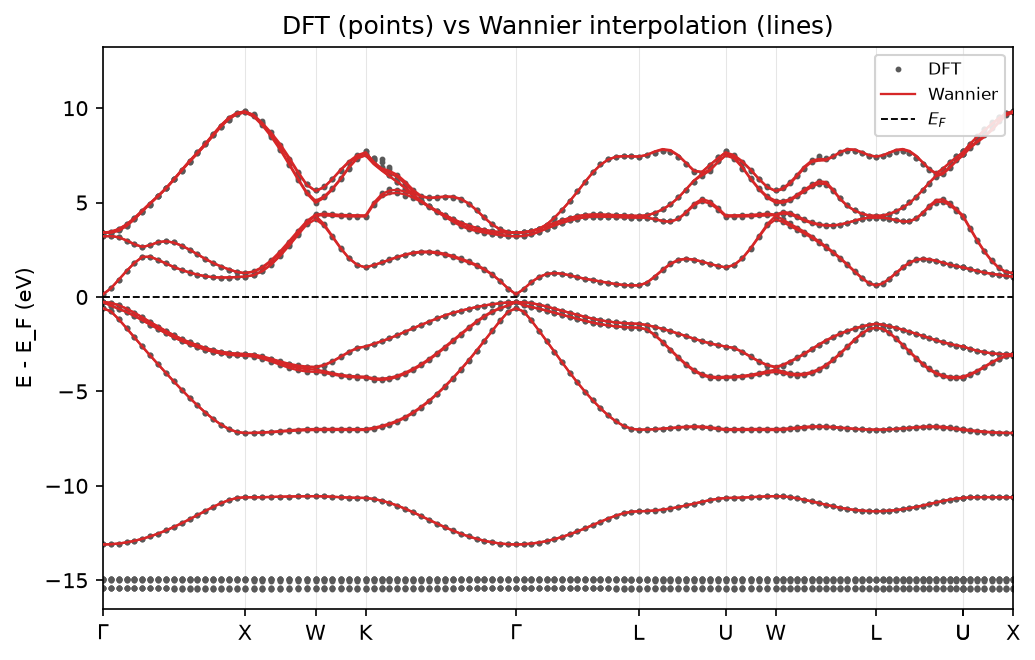

on-mesh fidelity inside the frozen window: max 0.000 meV, rms 0.000 meV over 16000 states
                       within 1 eV of E_F: max 0.000 meV


In [3]:
# --- DFT vs Wannier bands + on-mesh fidelity ------------------------------
from waw.interfaces.ase.structure import band_path as _bpath
from waw.interfaces.quantum_espresso import bands_along_path as _dft_path
from waw.core.hamiltonian import interpolate_bands as _interp
from waw.analysis.bands import mesh_fidelity as _fidelity
from waw.vis import plot_wannierization_windows as _plot_win

_EF, _OUTER, _FROZEN = E_FERMI, None, None
_bp = _bpath(atoms, npoints=120)
_xc, _xs, _lab = _bp.get_linear_kpoint_axis()
_wann = _interp(result.hr, _bp.kpts) * HARTREE_TO_EV
try:
    _dft = _dft_path(WORK, 'gaas_shc', _bp.kpts, ncores=NCORES)
except Exception as _exc:
    _dft = None
    print(f'ab-initio path bands unavailable ({type(_exc).__name__}: {_exc}) -- '
          f'showing the interpolation alone; the on-mesh numbers below still hold')

_fig, _ax = plt.subplots(figsize=(7, 4.5), dpi=150)
_plot_win(_ax, _xc, _dft if _dft is not None else np.full_like(_wann, np.nan), _wann,
          outer_window=_OUTER, frozen_window=_FROZEN, fermi_energy=_EF,
          xticks=_xs, xticklabels=[_l.replace('G', r'$\Gamma$') for _l in _lab])
_ax.set_ylabel('E - E_F (eV)')
_ax.set_title('DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

_fid = _fidelity(result.hr, ov['kpts'], ov['eig'], window=_FROZEN, fermi_ev=_EF)
print(f"on-mesh fidelity inside the frozen window: max {_fid['max']:.3f} meV, "
      f"rms {_fid['rms']:.3f} meV over {_fid['n_states']} states")
if 'max_near_ef' in _fid:
    print(f"                       within 1 eV of E_F: max {_fid['max_near_ef']:.3f} meV")


### 2. Scissors shift + the spin Hall R-space operators
`apply_scissors_shift` opens the DFT-underestimated gap by rigidly shifting the top 8 (conduction) bands up by 1.117 eV -- the real tutorial's own value, `num_valence_bands = 8` -- leaving the converged Wannier gauge and every gauge-derived quantity below untouched. The spin operators reuse `build_shc_operators` verbatim from tutorial 29 (no new physics needed for a different material).

In [4]:
hr_shifted = apply_scissors_shift(
    result.hr, W, result.wdata.kpts, MP_GRID, REAL,
    num_valence_bands=8, scissors_shift=1.117 * EV_TO_HARTREE,
)

AA_R = compute_position_r(result.m_tilde, result.wdata.wb, result.wdata.bvecs,
                          result.wdata.kpts, MP_GRID, REAL)
SS_R, SR_R, SHR_R, SH_R = build_shc_operators(
    W, result.wdata.Mmn, result.wdata.kb_idx, ov['spn'], result.wdata.eig,
    result.wdata.wb, result.wdata.bvecs, result.wdata.kpts, MP_GRID, REAL,
)
print('SS_R, SR_R, SHR_R, SH_R built:', SS_R.shape, SR_R.shape, SHR_R.shape, SH_R.shape)

SS_R, SR_R, SHR_R, SH_R built: torch.Size([1163, 16, 16, 3]) torch.Size([3, 3, 1163, 16, 16]) torch.Size([3, 3, 1163, 16, 16]) torch.Size([1163, 16, 16, 3])


### 3. Spin Hall conductivity vs. frequency
$\sigma^{xy}_z(\omega)$ (`alpha=0, beta=1, gamma=2`) at the fixed Fermi energy, scanned 0-8 eV in 0.01 eV steps -- the real tutorial's own `kubo_freq_min/max/step` -- with adaptive smearing (`kubo_adpt_smr_fac=1.414, kubo_adpt_smr_max=1.0`, the real tutorial's own explicit overrides of postw90's defaults).

sigma(omega) shape (801,) dtype complex128


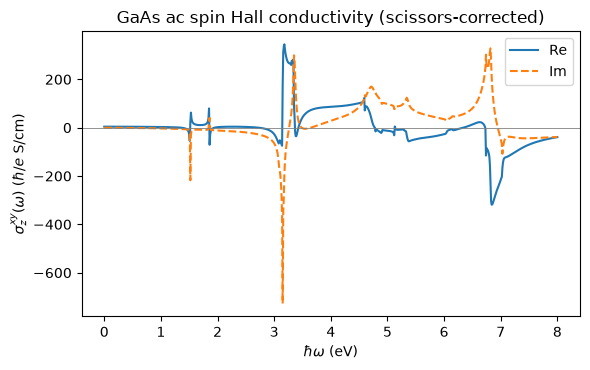

In [5]:
from waw.units import to_si_units

CELL_VOLUME_BOHR3 = abs(np.linalg.det(REAL))
OMEGA = np.arange(0.0, 8.0 + 1e-9, 0.01)
shc_ac = spin_hall_conductivity_ac(
    hr_shifted, AA_R, SS_R, SR_R, SHR_R, SH_R, RECIP, REAL,
    fermi_energy=E_FERMI * EV_TO_HARTREE, omega=OMEGA * EV_TO_HARTREE, mesh=(25, 25, 25),
    alpha=0, beta=1, gamma=2, kubo_adpt_smr=True,
    kubo_adpt_smr_fac=1.414, kubo_adpt_smr_max=1.0 * EV_TO_HARTREE,
)
shc_ac_sigma = to_si_units(shc_ac.sigma, 'spin_hall_conductivity', cell_volume_bohr3=CELL_VOLUME_BOHR3)
print('sigma(omega) shape', shc_ac_sigma.shape, 'dtype', shc_ac_sigma.dtype)

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(OMEGA, shc_ac_sigma.real, label='Re')
ax.plot(OMEGA, shc_ac_sigma.imag, label='Im', ls='--')
ax.axhline(0.0, color='0.5', lw=0.6)
ax.set_xlabel(r'$\hbar\omega$ (eV)'); ax.set_ylabel(r'$\sigma^{xy}_z(\omega)$ ($\hbar/e$ S/cm)')
ax.set_title('GaAs ac spin Hall conductivity (scissors-corrected)')
ax.legend(); plt.tight_layout(); plt.show()

**Takeaway.** `waw.analysis.spin_hall.spin_hall_conductivity_ac` reimplements postw90's frequency-domain SHC branch -- the same spin-current operator as tutorial 29's static case, but a genuinely different complex-pole accumulation formula -- and exercises the new `apply_scissors_shift` (a transcription of wannier90's own `get_HH_R` scissors block, verified to leave every wavefunction-derived quantity exactly unchanged) on a real semiconductor gap correction. See `project_waw.md`'s tutorial30 entry for the cross-validation record against real `wannier90.x`/`postw90.x` on this exact system.